# Kiểm thử Data Augmentation (Albumentations)
Mục tiêu:
Đảm bảo khi áp dụng các phép xoay, lật ảnh, phóng to thu nhỏ (nhằm chống Overfitting), thì cả **Mask** và tọa độ **Bounding Box** đều được biến đổi khớp 100% với ảnh gốc.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import albumentations as A

# Định nghĩa đường dẫn tới thư mục ĐÃ TIỀN XỬ LÝ (Processed)
PROCESSED_IMG_DIR = "../data/processed/train/images"
PROCESSED_MASK_DIR = "../data/processed/train/masks"
CSV_PATH = "../data/processed/train_bboxes.csv"

In [2]:
# Tạo một pipeline augmentation "nặng đô" để test
transform = A.Compose([
    A.HorizontalFlip(p=1.0),                  # Lật ngang 100%
    A.VerticalFlip(p=1.0),                    # Lật dọc 100%
    A.RandomRotate90(p=1.0),                  # Xoay 90 độ 100%
    A.ColorJitter(brightness=0.4, contrast=0.4, p=1.0) # Đổi màu
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

In [3]:
def visualize_augmentation(img_id, df):
    # Lấy thông tin từ CSV
    row = df[df['image_id'] == img_id].iloc[0]
    bbox = [[row['x_min'], row['y_min'], row['x_max'], row['y_max']]]
    
    img_path = f"{PROCESSED_IMG_DIR}/{img_id}.jpg"
    mask_path = f"{PROCESSED_MASK_DIR}/{img_id}.png"
    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # 1. TRƯỚC KHI BIẾN ĐỔI (BEFORE)
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    fig.suptitle(f"Image ID: {img_id}", fontsize=16, fontweight='bold')
    
    axes[0, 0].imshow(image)
    rect1 = patches.Rectangle((bbox[0][0], bbox[0][1]), bbox[0][2]-bbox[0][0], bbox[0][3]-bbox[0][1], 
                              linewidth=2, edgecolor='red', facecolor='none')
    axes[0, 0].add_patch(rect1)
    axes[0, 0].set_title("Original Image + BBox")
    
    axes[0, 1].imshow(mask, cmap='gray')
    axes[0, 1].set_title("Original Mask")
    
    # 2. ÁP DỤNG BIẾN ĐỔI
    transformed = transform(image=image, mask=mask, bboxes=bbox, class_labels=[1])
    t_image = transformed['image']
    t_mask = transformed['mask']
    t_bbox = transformed['bboxes']
    
    # 3. SAU KHI BIẾN ĐỔI (AFTER)
    axes[1, 0].imshow(t_image)
    if len(t_bbox) > 0:
        b = t_bbox[0]
        rect2 = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], 
                                  linewidth=2, edgecolor='lime', facecolor='none')
        axes[1, 0].add_patch(rect2)
    axes[1, 0].set_title("Transformed Image + BBox")
    
    axes[1, 1].imshow(t_mask, cmap='gray')
    axes[1, 1].set_title("Transformed Mask")
    
    plt.tight_layout()
    plt.show()

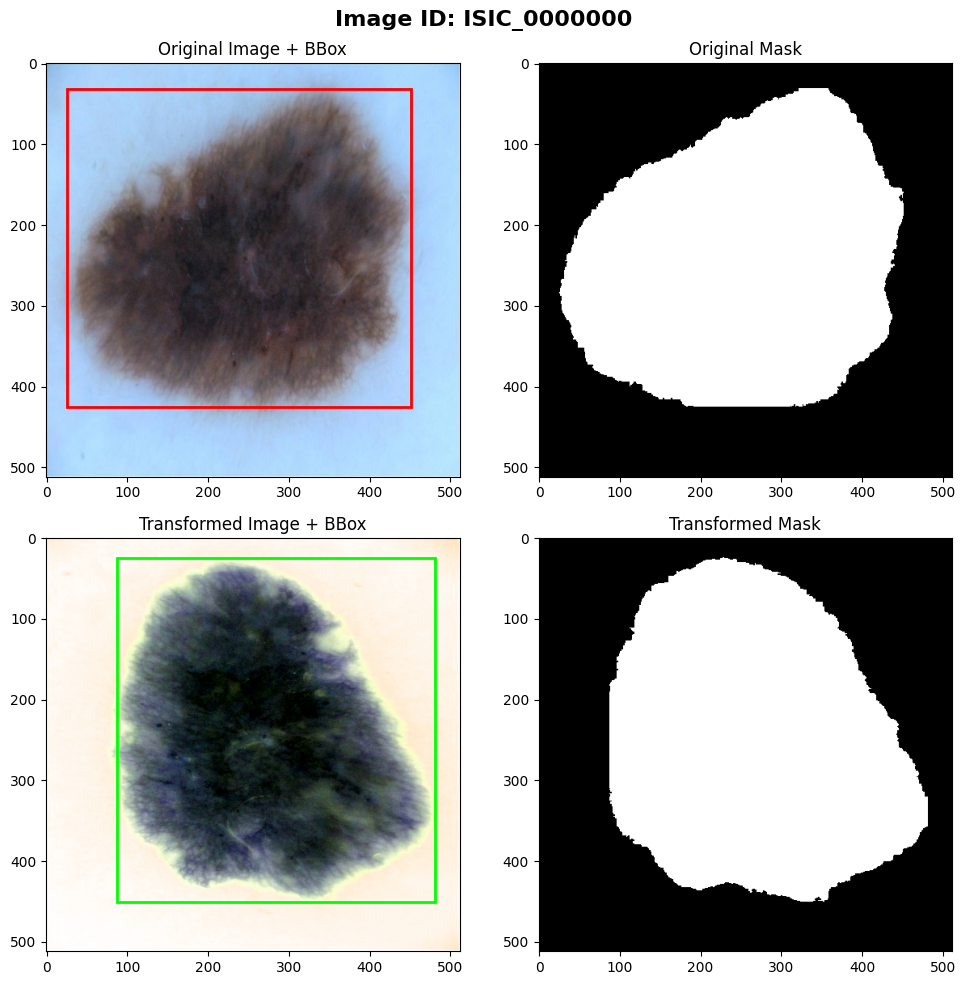

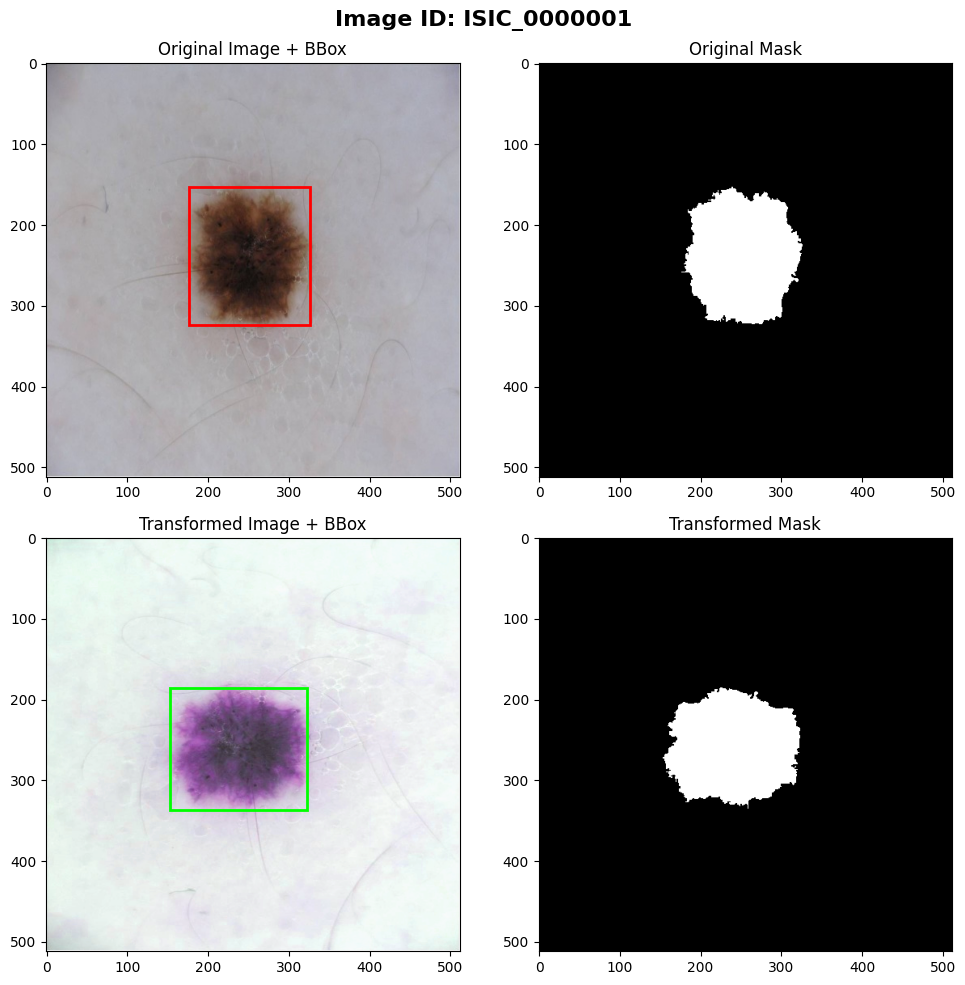

In [4]:
# Đọc CSV file
df = pd.read_csv(CSV_PATH)

# Lấy thử 2 ảnh đầu tiên trong file CSV
sample_ids = df['image_id'].head(2).tolist()

for img_id in sample_ids:
    visualize_augmentation(img_id, df)